In [ ]:
import os
import random
import time
from pathlib import Path
from tqdm import tqdm
import numpy as np
from PIL import Image
from datetime import datetime
import csv
import json
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.models import vit_b_16, ViT_B_16_Weights

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from jpeg_aug import RandomJPEGCompression

In [2]:
# Checking Device/confirming it works with CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


In [ ]:
# Helper Functions

def subset_dataset(dataset, percent, seed=6050):
    if percent >= 1.0:
        return dataset
    
    random.seed(seed)
    subset_size = int(len(dataset) * percent)
    indices = random.sample(range(len(dataset)), subset_size)
    return Subset(dataset, indices)

def plot_loss_and_acc(track_loss, track_train_acc, track_val_acc):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(track_train_acc, label="Train")
    plt.plot(track_val_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(track_loss, label="Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

def get_dataset_records(dataset, split_name):
    """
    Returns: list of dicts: {image_path, image_type, image_split}
    Works for both ImageFolder and Subset.
    """

    records = []

    # Determine base dataset (ImageFolder) and indices
    if isinstance(dataset, torch.utils.data.Subset):
        base = dataset.dataset
        indices = dataset.indices
    else:
        base = dataset
        indices = range(len(dataset))

    # Reverse mapping: 0→Real, 1→Fake
    label_map = {0: "real", 1: "fake"}

    # Collect rows
    for idx in indices:
        path, label = base.samples[idx]  # (full_path, original_label)

        # Apply label swap: real=0, fake=1
        correct_label = 1 - label
        label_name = label_map[correct_label]

        # Keep last 3 parts of path
        short_path = "/".join(Path(path).parts[-3:])

        records.append({
            "image_path": short_path,
            "image_type": label_name,
            "image_split": split_name
        })

    return records

def create_run_logger(model_name, params, timestamp, log_dir="logs"):
    os.makedirs(log_dir, exist_ok=True)

    # timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Create file paths
    log_txt = os.path.join(log_dir, f"{model_name}_run_{timestamp}.txt")
    log_json = os.path.join(log_dir, f"{model_name}_run_{timestamp}.json")

    # Initialize JSON log structure
    json_log = {
        "timestamp": timestamp,
        "model": model_name,
        "parameters": params,
        "epoch_data": []
    }

    # Write initial text header
    with open(log_txt, "w") as f:
        f.write("TRAINING RUN START \n")
        f.write(f"Timestamp: {timestamp}\n")
        f.write(f"Model: {model_name}\n")
        f.write("\nPARAMETERS \n")
        for k, v in params.items():
            f.write(f"{k}: {v}\n")
        f.write("\n==============================\n\n")

    return log_txt, log_json, json_log

def loading_data(train_dir, val_dir, transform, train_ratio = 1.0, batch_size=32, num_workers=0):

    train_dataset = CustomImageFolder(root=str(train_dir), transform=transform)
    val_dataset = CustomImageFolder(root=str(val_dir), transform=transform)

    print("Original class mapping:", train_dataset.class_to_idx)  # still 'fake':0, 'real':1

    if train_ratio >= 1.0 or train_ratio <= 0.0:
        print("Using all the data")
    else:
        train_dataset = subset_dataset(train_dataset, train_ratio)
        val_dataset = subset_dataset(val_dataset, train_ratio)
        print(f"Using {train_ratio*100}% of the data")

    #DATALOADERS
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    print(f"Training on {len(train_dataset)} images, validating on {len(val_dataset)} images.")

    # logging data splits
    train_records = get_dataset_records(train_dataset, "train")
    val_records = get_dataset_records(val_dataset, "validation")

    all_records = train_records + val_records

    csv_datetime = datetime.now().strftime('%Y%m%d_%H%M%S')
    csv_name = f"dataset_split_{csv_datetime}.csv"
    csv_path = f"logs/{csv_name}"

    os.makedirs("logs", exist_ok=True)

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["image_path", "image_type", "image_split"])
        writer.writeheader()
        writer.writerows(all_records)

    print(f"Saved dataset split CSV to: {csv_path}")
    print(f"Total records: {len(all_records)}")

    return train_loader, val_loader, train_dataset, val_dataset, csv_name

def make_loader_for_windows(dataset, real_indices, fake_indices_by_w, 
                            windows, batch_size, shuffle, num_workers=0):
    all_indices = list(real_indices)
    for w in windows:
        all_indices.extend(fake_indices_by_w[w])
    subset = Subset(dataset, all_indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)
    return loader, len(all_indices)

def create_run_logger(model_name, params, timestamp, log_dir="logs"):
    os.makedirs(log_dir, exist_ok=True)

    # Log file paths
    log_txt = os.path.join(log_dir, f"{model_name}_run_{timestamp}.txt")
    log_json = os.path.join(log_dir, f"{model_name}_run_{timestamp}.json")

    # JSON structure
    json_log = {
        "timestamp": timestamp,
        "model": model_name,
        "parameters": params,
        "steps": []   # < sliding steps
    }

    # TXT file
    with open(log_txt, "w") as f:
        f.write("TRAINING RUN START\n")
        f.write(f"Timestamp: {timestamp}\n")
        f.write(f"Model: {model_name}\n\n")
        f.write("PARAMETERS:\n")
        for k, v in params.items():
            f.write(f"  {k}: {v}\n")
        f.write("\n==============================\n\n")

    return log_txt, log_json, json_log

def logger_add_step(json_log, step_index, windows_used):
    step_entry = {
        "step": step_index,
        "windows_used": windows_used,
        "epochs": []   # epochs get appended inside this
    }
    json_log["steps"].append(step_entry)

def logger_add_epoch(json_log, step_index, epoch_index, metrics):
    """
    metrics = {
        "train_loss": ...,
        "train_acc": ...,
        "val_past_acc": ...,
        "val_next_acc": ...,
        "val_all_acc": ...,
        ..............,
        "epoch_minutes": ...
    }
    """
    json_log["steps"][step_index]["epochs"].append({
        "epoch": epoch_index,
        **metrics
    })

def save_json_log(json_log, json_path):
    with open(json_path, "w") as f:
        json.dump(json_log, f, indent=4)

# dataloader loads alphabetically, so we need to swap labels
class CustomImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        # Swap label: make 'real' = 0, 'fake' = 1
        label = 1 - label
        return img, label, index

In [ ]:
def eval_metrics(
    model,
    loader,
    device,
    desc="Evaluating",
    fake_indices_by_w=None,
    current_seen_windows=None
):
    """
    Computes full evaluation metrics:
        - Accuracy
        - Precision (macro)
        - Recall (macro)
        - F1 (macro)
        - ROC-AUC (binary)
        - Seen F1 (AI-GenBench)
        - Unseen F1 (AI-GenBench)
    """

    model.eval()
    all_labels = []
    all_preds = []
    all_scores = []     # Softmax prob for ROC-AUC (class=1 fake)

    # Track seen/unseen groups
    seen_labels = []
    seen_preds = []
    unseen_labels = []
    unseen_preds = []

    # Precompute set for easy lookup
    seen_indices = set()
    unseen_indices = set()
    if fake_indices_by_w is not None and current_seen_windows is not None:
        for w in current_seen_windows:
            seen_indices.update(fake_indices_by_w[w])
        # All windows except current_seen_windows are unseen
        for w, idx_list in fake_indices_by_w.items():
            if w not in current_seen_windows:
                unseen_indices.update(idx_list)

    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, unit="batch", leave=False)
        for batch_idx, (images, labels, indices) in enumerate(pbar):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, predicted = outputs.max(1)

            labels_np = labels.cpu().numpy()
            preds_np = predicted.cpu().numpy()
            scores_np = probs.cpu().numpy()
            indices_np = indices.cpu().numpy()

            all_labels.extend(labels_np)
            all_preds.extend(preds_np)
            all_scores.extend(scores_np)

            # Track seen / unseen
            for j in range(len(labels_np)):
                global_idx = indices_np[j]    # <-- correct global dataset index

                if labels_np[j] == 1:         # only for fake class
                    if global_idx in seen_indices:
                        seen_labels.append(labels_np[j])
                        seen_preds.append(preds_np[j])
                    elif global_idx in unseen_indices:
                        unseen_labels.append(labels_np[j])
                        unseen_preds.append(preds_np[j])

    # ----- CORE METRICS -----
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    # ROC-AUC (need both classes)
    try:
        rocauc = roc_auc_score(all_labels, all_scores)
    except:
        rocauc = float("nan")

    # ----- Seen / Unseen F1 -----
    seen_f1 = f1_score(seen_labels, seen_preds, average="binary", zero_division=0) if len(seen_labels) > 0 else float("nan")
    unseen_f1 = f1_score(unseen_labels, unseen_preds, average="binary", zero_division=0) if len(unseen_labels) > 0 else float("nan")

    return {
        "accuracy": acc * 100,
        "precision_macro": precision * 100,
        "recall_macro": recall * 100,
        "f1_macro": f1macro * 100,
        "roc_auc": rocauc,
        "seen_f1": seen_f1 * 100,
        "unseen_f1": unseen_f1 * 100,
    }


In [4]:
# CONFIGURATION

data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")  # adjust as needed
train_dir = data_root / "train"
val_dir = data_root / "validation"

batch_size = 32
num_workers = 4
num_epochs = 5
learning_rate = 1e-4
train_percent = 1.0  # train/validate on percent of data

In [5]:
# DATA TRANSFORMS

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for ViT
    transforms.RandomHorizontalFlip(),
    RandomJPEGCompression(quality_range=(30, 95)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

'''
resize will resize the image to 224x224
randomhorizontalflip will randomly flip the image horizontally

toTensor will convert the image to a tensor
normalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on

'''

'\nresize will resize the image to 224x224\nrandomhorizontalflip will randomly flip the image horizontally\n\ntoTensor will convert the image to a tensor\nnormalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on\n\n'

In [6]:
train_loader, val_loader, train_dataset, val_dataset, csv_name = loading_data(train_dir, 
                                                                    val_dir, 
                                                                    transform, 
                                                                    train_ratio = train_percent,
                                                                    batch_size=batch_size, 
                                                                    num_workers=0)

Original class mapping: {'fake': 0, 'real': 1}
Using all the data
Training on 115200 images, validating on 28340 images.
Saved dataset split CSV to: logs/dataset_split_20251130_094845.csv
Total records: 143540


In [7]:
# Paths to your fake CSVs (adjust names/paths as needed) ---
train_fake_csv_path = r'C:/Users/Jimmy/OneDrive/Desktop/ID_of_AI_Images/temporal_validation/fake_train_temporal_splits.csv'
val_fake_csv_path = r'C:/Users/Jimmy/OneDrive/Desktop/ID_of_AI_Images/temporal_validation/fake_validation_temporal_splits.csv'

train_fake_df = pd.read_csv(train_fake_csv_path)
val_fake_df = pd.read_csv(val_fake_csv_path)

# Ensure filename column is just the basename (in case it has paths)
train_fake_df["filename"] = train_fake_df["filename"].apply(os.path.basename)
val_fake_df["filename"] = val_fake_df["filename"].apply(os.path.basename)

# Map: filename -> window
train_file_to_window = dict(zip(train_fake_df["filename"], train_fake_df["w_split"]))
val_file_to_window = dict(zip(val_fake_df["filename"],   val_fake_df["w_split"]))

# Determine max window index
max_train_w = train_fake_df["w_split"].max()
max_val_w = val_fake_df["w_split"].max()
max_w = int(max(max_train_w, max_val_w))

print(f"Max window index detected: {max_w}")

Max window index detected: 8


In [8]:
# Handle Subset and Full Dataset
def get_base_dataset(ds):
    """Return (base_dataset, indices_list) whether ds is Subset or full dataset."""
    if isinstance(ds, torch.utils.data.Subset):
        return ds.dataset, ds.indices
    else:
        return ds, list(range(len(ds)))

base_train_ds, train_indices = get_base_dataset(train_dataset)
base_val_ds, val_indices   = get_base_dataset(val_dataset)

FAKE_CLASS = base_train_ds.class_to_idx["fake"]  # flipped: fake=0, real=1
REAL_CLASS = base_train_ds.class_to_idx["real"]

# Create mapping: index_in_train_dataset → actual_path_and_class
train_samples = base_train_ds.samples
val_samples   = base_val_ds.samples

# Determine max window
max_train_w = train_fake_df["w_split"].max()
max_val_w = val_fake_df["w_split"].max()
max_w = int(max(max_train_w, max_val_w))

# Storage structures
train_fake_indices_by_w = {w: [] for w in range(max_w + 1)}
val_fake_indices_by_w = {w: [] for w in range(max_w + 1)}
train_real_indices = []
val_real_indices = []

# Build TRAIN indices properly whether subset or not
for new_i, original_i in enumerate(train_indices):
    path, cls = train_samples[original_i]
    fname = os.path.basename(path)

    if cls == REAL_CLASS:
        train_real_indices.append(new_i)

    elif cls == FAKE_CLASS:
        if fname in train_file_to_window:
            w = int(train_file_to_window[fname])
            train_fake_indices_by_w[w].append(new_i)
        else:
            print(f"[WARN] Train fake missing from CSV: {fname}")

# Build VAL indices properly
for new_i, original_i in enumerate(val_indices):
    path, cls = val_samples[original_i]
    fname = os.path.basename(path)

    if cls == REAL_CLASS:
        val_real_indices.append(new_i)

    elif cls == FAKE_CLASS:
        if fname in val_file_to_window:
            w = int(val_file_to_window[fname])
            val_fake_indices_by_w[w].append(new_i)
        else:
            print(f"[WARN] Val fake missing from CSV: {fname}")

print("Train real:", len(train_real_indices))
for w in range(max_w + 1):
    print(f"Train fake w{w}: {len(train_fake_indices_by_w[w])}")

print("Val real:", len(val_real_indices))
for w in range(max_w + 1):
    print(f"Val fake w{w}: {len(val_fake_indices_by_w[w])}")


Train real: 57600
Train fake w0: 6364
Train fake w1: 6455
Train fake w2: 6501
Train fake w3: 6385
Train fake w4: 6268
Train fake w5: 6411
Train fake w6: 6370
Train fake w7: 6387
Train fake w8: 6459
Val real: 14170
Val fake w0: 1545
Val fake w1: 1604
Val fake w2: 1524
Val fake w3: 1570
Val fake w4: 1600
Val fake w5: 1594
Val fake w6: 1559
Val fake w7: 1587
Val fake w8: 1587


In [ ]:
subset = train_dataset

for idx in range(10):
    if isinstance(subset, torch.utils.data.Subset):
        actual_idx = subset.indices[idx]
        img, label,_ = subset[idx]
        path = subset.dataset.imgs[actual_idx][0]
    else:
        img, label,_ = subset[idx]
        path = subset.imgs[idx][0]

    print(f"{path} --> Label: {label}")

C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000001.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000002.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000003.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000004.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000006.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000008.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000012.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000013.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000014.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000017.png --> Label: 1


In [10]:
# MODEL SETUP ViT

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)

model.heads.head = nn.Sequential(
    nn.LayerNorm(model.heads.head.in_features),
    nn.Linear(model.heads.head.in_features, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

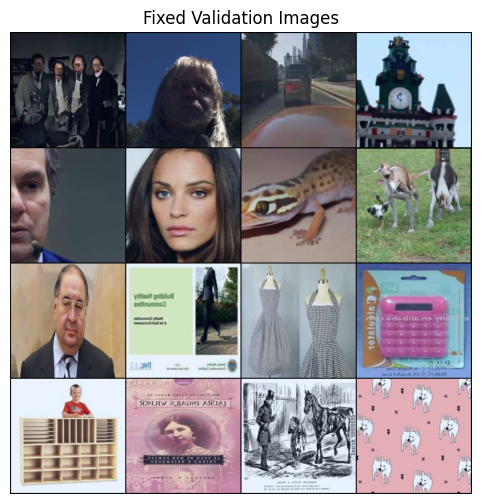

Fake: 018206.png
Fake: 032722.png
Fake: 006281.png
Fake: 014024.png
Fake: 035496.png
Fake: 002407.png
Fake: 006533.png
Fake: 026761.png
Real: 0001837.png
Real: 0010086.png
Real: 0016490.png
Real: 0017833.png
Real: 0011609.png
Real: 0004573.png
Real: 0003025.png
Real: 0025669.png


In [11]:
# SEED = 42
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)

grid_size = 4
num_images = grid_size * grid_size

if isinstance(val_dataset, torch.utils.data.Subset):
    subset = val_dataset
    base = val_dataset.dataset

    all_indices = subset.indices
    all_paths  = [base.samples[i][0] for i in all_indices]
    all_labels = [base.samples[i][1] for i in all_indices]

else:
    all_paths  = [p for p, l in val_dataset.samples]
    all_labels = [l for p, l in val_dataset.samples]

labels_tensor = torch.tensor(all_labels)

real_indices = (labels_tensor == 0).nonzero(as_tuple=True)[0]
fake_indices = (labels_tensor == 1).nonzero(as_tuple=True)[0]

half_num = num_images // 2
real_sample = real_indices[torch.randperm(len(real_indices))[:half_num]]
fake_sample = fake_indices[torch.randperm(len(fake_indices))[:half_num]]

subset_indices = torch.cat([real_sample, fake_sample])

if isinstance(val_dataset, torch.utils.data.Subset):
    base = val_dataset.dataset
    original_indices = [all_indices[i.item()] for i in subset_indices]

    fixed_images = torch.stack([base[i][0] for i in original_indices]).to(device)
    fixed_labels = torch.tensor([base[i][1] for i in original_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

else:
    fixed_images = torch.stack([val_dataset[i][0] for i in subset_indices]).to(device)
    fixed_labels = torch.tensor([val_dataset[i][1] for i in subset_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

grid_img = make_grid(fixed_images.cpu(), nrow=grid_size, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid_img.numpy(), (1,2,0)))
plt.axis("off")
plt.title("Fixed Validation Images")
plt.show()

for path, lbl in zip(fixed_paths, fixed_labels):
    print(f"{'Real' if lbl==0 else 'Fake'}: {os.path.basename(path)}")


In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_pbar = tqdm(train_loader, desc="Training", unit="batch")
    for images, labels, _ in train_pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
        train_acc = 100.0 * correct / total

        train_pbar.set_postfix({
            "Loss": f"{avg_loss:.4f}",
            "Train Acc": f"{train_acc:.2f}%"
        })

    avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
    train_acc = 100.0 * correct / total if total > 0 else 0.0
    return avg_loss, train_acc


def eval_accuracy(model, loader, device, desc="Evaluating"):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, unit="batch", leave=False)
        for images, labels, _ in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = 100.0 * correct / total if total > 0 else 0.0
    return acc


In [ ]:
def sliding_window_training(
    model,
    criterion,
    optimizer,
    train_dataset,
    val_dataset,
    train_real_indices,
    train_fake_indices_by_w,
    val_real_indices,
    val_fake_indices_by_w,
    max_w,
    num_epochs_per_step,
    batch_size,
    device,
    model_name="Temporal_ViT",
    num_workers=0,
    csv_name_used = None
):
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    if csv_name_used is None:
        csv_name_used = "none provided"

    params = {
        "model": model_name,
        "dataset split used:": csv_name_used,
        "max_w": max_w,
        "epochs_per_step": num_epochs_per_step,
        "batch_size": batch_size,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }

    log_txt, log_json_path, json_log = create_run_logger(
        model_name=model_name,
        params=params,
        timestamp=timestamp
    )

    # Log device + dataset sizes
    device_info = str(device)
    if device.type == "cuda":
        device_info += f" ({torch.cuda.get_device_name(0)})"
        print(f"Using device: {device_info}")
    else:
        device_info += " (CPU)"
        print(f"Using device: {device_info}")

    with open(log_txt, "a") as f:
        f.write(f"Using device: {device_info}\n")
        f.write(f"Using dataset: {csv_name_used}\n")
        f.write(f"Using model: {model_name }\n")
        f.write(f"Using max sliding window: {max_w}\n")
        f.write(f"Using epochs per step: {num_epochs_per_step}\n")
        f.write(f"Using batch size: {batch_size}\n")
        f.write(f"Using learning rate: {optimizer.param_groups[0]['lr']}\n")
        f.write(f"Dataset sizes: Train: {len(train_dataset)}, Val: {len(val_dataset)}\n\n")

    history = []
    start_time = time.time()
    best_val_acc = 0

    for k in range(0, max_w):  # last step is k=max_w-1 with next window = max_w
        print("\n" + "="*70)
        print(f" - Sliding step {k}: train on w[0..{k}], validate on w{ k+1 }")
        print("="*70)

        logger_add_step(
            json_log,
            step_index=k,
            windows_used=list(range(0, k+1))
        )

        past_windows = list(range(0, k+1))
        next_window  = k + 1
        all_up_to_next = list(range(0, max_w+1))

        # Build loaders
        train_loader, n_train = make_loader_for_windows(
            train_dataset,
            train_real_indices,
            train_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers
        )

        val_past_loader, n_val_past = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_next_loader, n_val_next = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            [next_window],
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_all_loader, n_val_all = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            all_up_to_next,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        print(f"Train: {n_train} samples (Real + Fake windows {past_windows})")
        print(f"Val past: {n_val_past} samples (windows {past_windows})")
        print(f"Val next: {n_val_next} samples (window {next_window})")
        print(f"Val all: {n_val_all} samples (windows {all_up_to_next})")

        with open(log_txt, "a") as f:
            f.write(f"Step: {k}\n")
            f.write(f" * Sliding step {k}: train on w[0..{k}], validate on w{ k+1 }\n")
            f.write(f"Train: {n_train} samples (Real + Fake windows {past_windows})\n")
            f.write(f"Val past: {n_val_past} samples (windows {past_windows})\n")
            f.write(f"Val next: {n_val_next} samples (window {next_window})\n")
            f.write(f"Val all: {n_val_all} samples (windows {all_up_to_next})\n\n")

        # Train for num_epochs_per_step on current window setup
        for epoch in range(num_epochs_per_step):
            epoch_start_time = time.time()
            print(f"\n[Step {k}] Epoch {epoch+1}/{num_epochs_per_step}")

            train_loss, train_acc = train_one_epoch(
                model, train_loader, criterion, optimizer, device
            )

            # # Three validations
            # acc_past = eval_accuracy(model, val_past_loader, device, desc="Val past")
            # acc_next = eval_accuracy(model, val_next_loader, device, desc="Val next")
            # acc_all = eval_accuracy(model, val_all_loader,  device, desc="Val all")

            metrics_past = eval_metrics(
            model,
            val_past_loader,
            device,
            desc="Val past",
            fake_indices_by_w=val_fake_indices_by_w,
            current_seen_windows=past_windows)

            metrics_next = eval_metrics(
            model,
            val_next_loader,
            device,
            desc="Val Next",
            fake_indices_by_w=val_fake_indices_by_w,
            current_seen_windows=[next_window])

            metrics_all = eval_metrics(
            model,
            val_all_loader,
            device,
            desc="Val All",
            fake_indices_by_w=val_fake_indices_by_w,
            current_seen_windows=all_up_to_next)

            # Accuracy
            acc_past = metrics_past["accuracy"]
            acc_next = metrics_next["accuracy"]
            acc_all = metrics_all["accuracy"]

            # Precision
            prec_past = metrics_past['precision_macro']
            prec_next = metrics_next['precision_macro']
            prec_all = metrics_all['precision_macro']

            # Recall
            recall_past = metrics_past['recall_macro']
            recall_next = metrics_next['recall_macro']
            recall_all = metrics_all['recall_macro']

            # F1
            f1_past = metrics_past['f1_macro']
            f1_next = metrics_next['f1_macro']
            f1_all = metrics_all['f1_macro']

            # SEEN F1
            seen_f1_past = metrics_past['seen_f1']
            seen_f1_next = metrics_next['seen_f1']
            seen_f1_all = metrics_all['seen_f1']

            # SEEN F1
            unseen_f1_past = metrics_past['unseen_f1']
            unseen_f1_next = metrics_next['unseen_f1']
            unseen_f1_all = metrics_all['unseen_f1']

            # ROC-AUC
            aroc_past = metrics_past['roc_auc']
            aroc_next = metrics_next['roc_auc']
            aroc_all = metrics_all['roc_auc'] 

            print(
                f"[Step {k} | Epoch {epoch+1}] \n"
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | \n"
                f"Acc_ValPast: {acc_past:.2f}% | Acc_ValNext: {acc_next:.2f}% | Acc_ValAll: {acc_all:.2f}% \n"
                f"Prec_ValPast: {prec_past:.2f}% | Prec_ValNext: {prec_next:.2f}% | Prec_ValAll: {prec_all:.2f}% \n"
                f"Recall_ValPast: {recall_past:.2f}% | Recall_ValNext: {recall_next:.2f}% | Recall_ValAll: {recall_all:.2f}% \n"
                f"F1_ValPast: {f1_past:.2f}% | F1_ValNext: {f1_next:.2f}% | F1_ValAll: {f1_all:.2f}% \n"
                f"Seen_F1_ValPast: {seen_f1_past:.2f}% | Seen_F1_ValNext: {seen_f1_next:.2f}% | Seen_F1_ValAll: {seen_f1_all:.2f}% \n"
                f"Unseen_F1_ValPast: {unseen_f1_past:.2f}% | Unseen_F1_ValNext: {unseen_f1_next:.2f}% | Unseen_F1_ValAll: {unseen_f1_all:.2f}% \n"
                f"AROC_ValPast: {aroc_past:.2f} | AROC_ValNext: {aroc_next:.2f} | AROC_ValAll: {aroc_all:.2f} \n"
            )

            history.append({
                "step": k,
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                ########################
                "val_past_acc": acc_past,
                "val_next_acc": acc_next,
                "val_all_acc": acc_all,
                #######################
                "val_past_prec": prec_past,
                "val_next_prec": prec_next,
                "val_all_prec": prec_all,
                #######################
                "val_past_recall": recall_past,
                "val_next_recall": recall_next,
                "val_all_recall": recall_all,
                #######################
                "val_past_f1": f1_past,
                "val_next_f1": f1_next,
                "val_all_f1": f1_all,
                #######################
                "val_past_seenf1": seen_f1_past,
                "val_next_seenf1": seen_f1_next,
                "val_all_seenf1": seen_f1_all,
                #######################
                "val_past_unseenf1": unseen_f1_past,
                "val_next_unseenf1": unseen_f1_next,
                "val_all_unseenf1": unseen_f1_all,
                #######################
                "val_past_aroc": aroc_past,
                "val_next_aroc": aroc_next,
                "val_all_aroc": aroc_all
            })
            total_epoch_minutes = (time.time() - epoch_start_time) / 60.0

            logger_add_epoch(
                json_log,
                step_index=k,
                epoch_index=epoch+1,
                metrics={
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    #######################
                    "val_past_acc": acc_past,
                    "val_next_acc": acc_next,
                    "val_all_acc": acc_all,
                    #######################
                    "val_past_prec": prec_past,
                    "val_next_prec": prec_next,
                    "val_all_prec": prec_all,
                    #######################
                    "val_past_recall": recall_past,
                    "val_next_recall": recall_next,
                    "val_all_recall": recall_all,
                    #######################
                    "val_past_f1": f1_past,
                    "val_next_f1": f1_next,
                    "val_all_f1": f1_all,
                    #######################
                    "val_past_seenf1": seen_f1_past,
                    "val_next_seenf1": seen_f1_next,
                    "val_all_seenf1": seen_f1_all,
                    #######################
                    "val_past_unseenf1": unseen_f1_past,
                    "val_next_unseenf1": unseen_f1_next,
                    "val_all_unseenf1": unseen_f1_all,
                    #######################
                    "val_past_aroc": aroc_past,
                    "val_next_aroc": aroc_next,
                    "val_all_aroc": aroc_all,
                    "epoch_minutes": total_epoch_minutes
                }
            )

            with open(log_txt, "a") as f:
                f.write(f"Step: {k} ; Epoch = : {epoch+1}\n")
                f.write(f"\tTrain Loss: {train_loss} ; Train Acc {train_acc}\n")
                f.write(f"\tVal Past Acc: {acc_past}\n")
                f.write(f"\tVal Next Acc: {acc_next}\n")
                f.write(f"\tVal All Acc: {acc_all}\n")
                ################################################
                f.write(f"\tVal Past Prec: {prec_past}\n")
                f.write(f"\tVal Next Prec: {prec_next}\n")
                f.write(f"\tVal All Prec: {prec_all}\n")
                ################################################
                f.write(f"\tVal Past Recall: {recall_past}\n")
                f.write(f"\tVal Next Recall: {recall_next}\n")
                f.write(f"\tVal All Recall: {recall_all}\n")
                ################################################
                f.write(f"\tVal Past F1: {f1_past}\n")
                f.write(f"\tVal Next F1: {f1_next}\n")
                f.write(f"\tVal All F1: {f1_all}\n")
                ################################################
                f.write(f"\tVal Past Seen F1: {seen_f1_past}\n")
                f.write(f"\tVal Next Seen F1: {seen_f1_next}\n")
                f.write(f"\tVal All Seen F1: {seen_f1_all}\n")
                ################################################
                f.write(f"\tVal Past Unseen F1: {unseen_f1_past}\n")
                f.write(f"\tVal Next Unseen F1: {unseen_f1_next}\n")
                f.write(f"\tVal All Unseen F1: {unseen_f1_all}\n")
                ################################################
                f.write(f"\tVal Past AROC: {aroc_past}\n")
                f.write(f"\tVal Next AROC: {aroc_next}\n")
                f.write(f"\tVal All AROC: {aroc_all}\n")

                if epoch+1 == num_epochs_per_step:
                    f.write(f"\tTotal Epoch Minutes {total_epoch_minutes:.2f}\n\n")
                    f.write(f"{'='*30}\n")
                else:
                    f.write(f"\tTotal Epoch Minutes {total_epoch_minutes:.2f}\n")

            if acc_all > best_val_acc:
                best_val_acc = acc_all
                torch.save(model.state_dict(), f"best_{model_name}_{timestamp}.pth")

            save_json_log(json_log, log_json_path)

            print(f"Total Epoch time: {total_epoch_minutes:.2f} minutes")

    total_minutes = (time.time() - start_time) / 60.0
    print(f"\nSliding-window training complete in {total_minutes:.2f} minutes.")

    with open(log_txt, "a") as f:
        f.write(f"Best Validation accuracy for all windows: {best_val_acc}")
        f.write(f"Training Complete in: {total_minutes:.2f} minutes.")

    return history

## Training

In [ ]:
num_epochs_per_step = 1

history = sliding_window_training(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    train_real_indices=train_real_indices,
    train_fake_indices_by_w=train_fake_indices_by_w,
    val_real_indices=val_real_indices,
    val_fake_indices_by_w=val_fake_indices_by_w,
    max_w=max_w,
    num_epochs_per_step=num_epochs_per_step,
    batch_size=batch_size,
    device=device,
    model_name="NEW_Temporal_ViT",
    num_workers=0,
    csv_name_used=csv_name
)

Using device: cuda (NVIDIA GeForce RTX 4070 Ti)

 - Sliding step 0: train on w[0..0], validate on w1
Train: 63964 samples (Real + Fake windows [0])
Val past: 15715 samples (windows [0])
Val next: 15774 samples (window 1)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 0] Epoch 1/1


Training: 100%|██████████| 1999/1999 [15:34<00:00,  2.14batch/s, Loss=0.2885, Train Acc=95.55%]


[Step 0 | Epoch 1] Train Loss: 0.2885 | Train Acc: 95.55% | ValPast: 95.97% | ValNext: 93.29% | ValAll: 66.53%
Total Epoch time: 23.49 minutes

 - Sliding step 1: train on w[0..1], validate on w2
Train: 70419 samples (Real + Fake windows [0, 1])
Val past: 17319 samples (windows [0, 1])
Val next: 15694 samples (window 2)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 1] Epoch 1/1


Training: 100%|██████████| 2201/2201 [15:05<00:00,  2.43batch/s, Loss=0.3631, Train Acc=90.68%]


[Step 1 | Epoch 1] Train Loss: 0.3631 | Train Acc: 90.68% | ValPast: 90.60% | ValNext: 91.79% | ValAll: 62.70%
Total Epoch time: 22.90 minutes

 - Sliding step 2: train on w[0..2], validate on w3
Train: 76920 samples (Real + Fake windows [0, 1, 2])
Val past: 18843 samples (windows [0, 1, 2])
Val next: 15740 samples (window 3)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 2] Epoch 1/1


...

[Step 5 | Epoch 1] Train Loss: 0.4018 | Train Acc: 86.93% | ValPast: 87.17% | ValNext: 89.47% | ValAll: 77.91%
Total Epoch time: 28.72 minutes

 - Sliding step 6: train on w[0..6], validate on w7
Train: 102354 samples (Real + Fake windows [0, 1, 2, 3, 4, 5, 6])
Val past: 25166 samples (windows [0, 1, 2, 3, 4, 5, 6])
Val next: 15757 samples (window 7)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 6] Epoch 1/1


Training: 100%|██████████| 3199/3199 [21:51<00:00,  2.44batch/s, Loss=0.4133, Train Acc=86.07%]


[Step 6 | Epoch 1] Train Loss: 0.4133 | Train Acc: 86.07% | ValPast: 86.23% | ValNext: 79.73% | ValAll: 80.29%
Total Epoch time: 30.60 minutes

 - Sliding step 7: train on w[0..7], validate on w8
Train: 108741 samples (Real + Fake windows [0, 1, 2, 3, 4, 5, 6, 7])
Val past: 26753 samples (windows [0, 1, 2, 3, 4, 5, 6, 7])
Val next: 15757 samples (window 8)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 7] Epoch 1/1


Training: 100%|██████████| 3399/3399 [23:08<00:00,  2.45batch/s, Loss=0.4514, Train Acc=83.13%]
                                                              

[Step 7 | Epoch 1] Train Loss: 0.4514 | Train Acc: 83.13% | ValPast: 83.33% | ValNext: 85.11% | ValAll: 80.01%
Total Epoch time: 32.39 minutes

Sliding-window training complete in 216.92 minutes.


In [15]:
hist_df = pd.DataFrame(history)
print(hist_df.head())


   step  epoch  train_loss  train_acc  val_past_acc  val_next_acc  val_all_acc
0     0      1    0.288518  95.549059     95.965638     93.286421    66.534933
1     1      1    0.363058  90.684332     90.599919     91.793042    62.699365
2     2      1    0.397149  87.609204     88.489094     92.782719    72.050106
3     3      1    0.398726  87.267271     86.998481     89.651237    76.665490
4     4      1    0.393944  87.540888     87.725435     92.869830    76.125618
